# Book Recommender Project

Books Scrapped from [goodreads](https://www.goodreads.com/book/popular_by_date/2019).

Books API from

Developed by: Bryan Calderon

Extracting the 10 most popular books per year!

#### **EDA**

* Importing libraries

In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import re
from urllib.parse import urljoin
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
# Loading data sets
df_good = pd.read_csv("data/GoodBooks_clean.csv")
df_API = pd.read_csv("data/API_Books_clean.csv")
print(df_good.info())
print("--"* 25)
print(df_API.info())

<class 'pandas.DataFrame'>
RangeIndex: 484 entries, 0 to 483
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   source_year     484 non-null    int64  
 1   book_url        484 non-null    str    
 2   source          484 non-null    str    
 3   title           484 non-null    str    
 4   author          484 non-null    str    
 5   average_rating  484 non-null    float64
 6   ratings_count   484 non-null    int64  
 7   reviews_count   484 non-null    int64  
 8   description     484 non-null    str    
 9   genres          484 non-null    str    
 10  pages           484 non-null    int64  
 11  image_url       484 non-null    str    
dtypes: float64(1), int64(4), str(7)
memory usage: 629.8 KB
None
--------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 745 entries, 0 to 744
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          

Convining data sets

In [19]:
common_columns = [
    "source_year",
    "title",
    "author",
    "average_rating",
    "ratings_count",
    "reviews_count",
    "description",
    "genres",
    "pages",
    "publisher",
    "book_url",
    "image_url",
    "source"]

df_good["publisher"] = "Unknown"
df_good = df_good[common_columns]
df_API = df_API[common_columns]

In [20]:
df3 = pd.concat([df_good, df_API], ignore_index=True)

In [21]:
df3.describe()

,source_year,average_rating,ratings_count,reviews_count,pages
count,1229.000000,1229.000000,1.229000e+03,1229.000000,484.000000
mean,1962.242474,4.022999,4.056924e+05,23057.337673,410.154959
std,35.708667,0.374192,8.989156e+05,49692.396591,191.539515
min,1900.000000,1.000000,1.000000e+00,0.000000,32.000000
25%,1932.000000,3.860000,1.100000e+01,0.000000,291.750000
50%,1962.000000,4.060000,4.500000e+01,0.000000,375.000000
75%,1993.000000,4.250000,4.478590e+05,18589.000000,483.000000
max,2024.000000,5.000000,1.163572e+07,405524.000000,1312.000000


In [22]:
df3.info()

<class 'pandas.DataFrame'>
RangeIndex: 1229 entries, 0 to 1228
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   source_year     1229 non-null   int64  
 1   title           1229 non-null   str    
 2   author          1229 non-null   str    
 3   average_rating  1229 non-null   float64
 4   ratings_count   1229 non-null   int64  
 5   reviews_count   1229 non-null   int64  
 6   description     1229 non-null   str    
 7   genres          1229 non-null   str    
 8   pages           484 non-null    float64
 9   publisher       1229 non-null   str    
 10  book_url        1229 non-null   str    
 11  image_url       1229 non-null   str    
 12  source          1229 non-null   str    
dtypes: float64(2), int64(3), str(8)
memory usage: 1.2 MB


In [23]:
# Using median to fill null on pages variables
median_pages = df3["pages"].median()
df3["pages"] = df3["pages"].fillna(median_pages).astype(int)  

In [28]:
df3 = df3.sort_values(by="source_year", ascending=True).reset_index(drop=True)

* First analysis

In [30]:
df3["author"].value_counts().head(10)
# Here also can say that the number of books by author

author
Agatha Christie         60
Georgette Heyer         25
Stephen  King           21
L. Frank Baum           15
Lucy Maud Montgomery    13
Isaac Asimov            13
Robert A. Heinlein      13
Sarah J. Maas           13
Edgar Rice Burroughs    11
Roald Dahl              11
Name: count, dtype: int64

<Axes: xlabel='average_rating', ylabel='Count'>

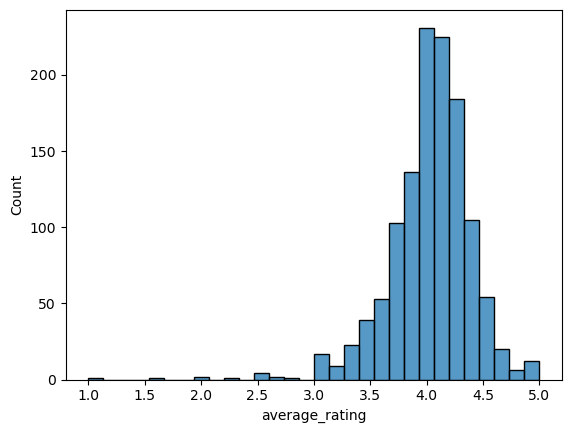

In [25]:
sns.histplot(df3["average_rating"], bins=30)

In [31]:
top_popular_books = (
    df3.sort_values("ratings_count", ascending=False)
    [["title", "author", "source_year", "average_rating", "ratings_count"]]
    .head(10)
)
top_popular_books

,title,author,source_year,average_rating,ratings_count
965,Harry Potter and the Philosopher's Stone,J.K. Rowling,1997,4.47,11635724
1067,The Hunger Games,Suzanne Collins,2008,4.35,10120960
1043,Twilight,Stephenie Meyer,2005,3.68,7426050
1101,The Fault in Our Stars,John Green,2012,4.12,5813639
980,Harry Potter and the Prisoner of Azkaban,J.K. Rowling,1999,4.58,4956577
1149,It Ends with Us,Colleen Hoover,2016,4.07,4743702
975,Harry Potter and the Chamber of Secrets,J.K. Rowling,1998,4.43,4591042
1100,Divergent,Veronica Roth,2011,4.13,4442400
1131,A Court of Thorns and Roses,Sarah J. Maas,2015,4.15,4426212
995,Harry Potter and the Goblet of Fire,J.K. Rowling,2000,4.57,4282921


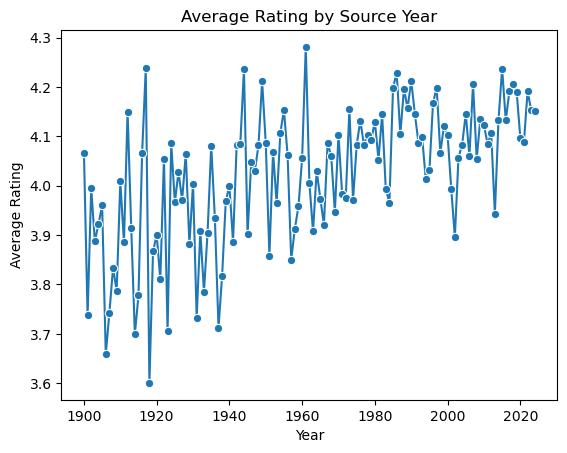

In [32]:
avg_rating_year = (df3.groupby("source_year")["average_rating"]
    .mean()
    .reset_index()
)

sns.lineplot(data=avg_rating_year,
    x="source_year",
    y="average_rating",
    marker="o"
)
plt.title("Average Rating by Source Year")
plt.xlabel("Year")
plt.ylabel("Average Rating")
plt.show()


<Axes: xlabel='pages', ylabel='Count'>

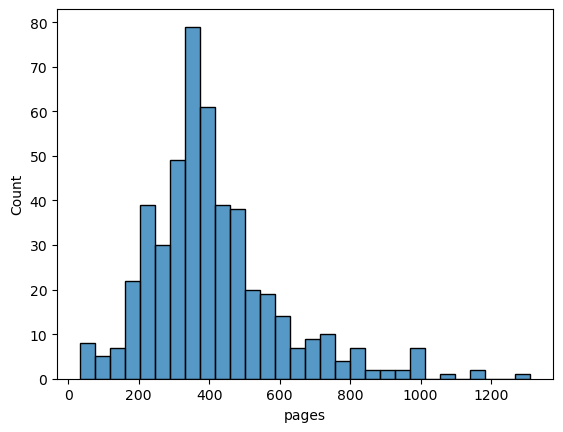

In [42]:
df_filtered = df3[df3["pages"] != 375].copy()
sns.histplot(df_filtered["pages"], bins=30)

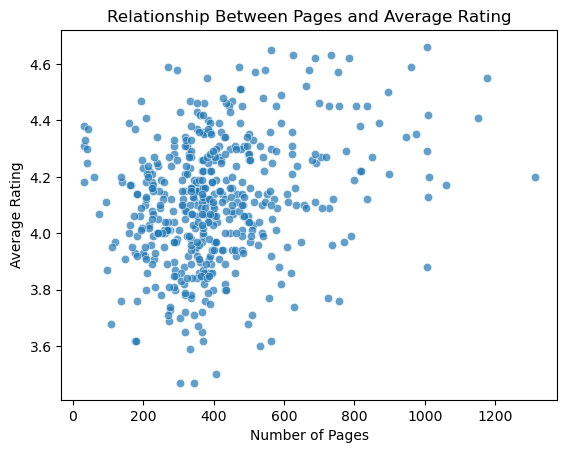

In [ ]:
df_filtered = df3[df3["pages"] != 375].copy()
sns.scatterplot(
    data=df_filtered,
    x="pages",
    y="average_rating",
    alpha=0.7
)

plt.title("Relationship Between Pages and Average Rating")
plt.xlabel("Number of Pages")
plt.ylabel("Average Rating")
plt.show()

In [ ]:
df_genres = df3.copy()
df_genres["genres"] = df_genres["genres"].str.split(", ")
df_genres = df_genres.explode("genres")
df_genres.head()

,source_year,title,author,average_rating,ratings_count,reviews_count,description,genres,pages,publisher,book_url,image_url,source
0,1900,The Hound of the Baskervilles,Arthur Conan Doyle,4.016667,60,0,The Hound of the Baskervilles Arthur Conan Doy...,crime novel,375,"Marti Yayinlari, Zeplin Kitap, Leopard, Saddle...",https://openlibrary.org/works/OL262454W,https://covers.openlibrary.org/b/id/8063264-M.jpg,Open Library API
0,1900,The Hound of the Baskervilles,Arthur Conan Doyle,4.016667,60,0,The Hound of the Baskervilles Arthur Conan Doy...,English Civil War,375,"Marti Yayinlari, Zeplin Kitap, Leopard, Saddle...",https://openlibrary.org/works/OL262454W,https://covers.openlibrary.org/b/id/8063264-M.jpg,Open Library API
0,1900,The Hound of the Baskervilles,Arthur Conan Doyle,4.016667,60,0,The Hound of the Baskervilles Arthur Conan Doy...,mires,375,"Marti Yayinlari, Zeplin Kitap, Leopard, Saddle...",https://openlibrary.org/works/OL262454W,https://covers.openlibrary.org/b/id/8063264-M.jpg,Open Library API
0,1900,The Hound of the Baskervilles,Arthur Conan Doyle,4.016667,60,0,The Hound of the Baskervilles Arthur Conan Doy...,tors,375,"Marti Yayinlari, Zeplin Kitap, Leopard, Saddle...",https://openlibrary.org/works/OL262454W,https://covers.openlibrary.org/b/id/8063264-M.jpg,Open Library API
0,1900,The Hound of the Baskervilles,Arthur Conan Doyle,4.016667,60,0,The Hound of the Baskervilles Arthur Conan Doy...,tombs,375,"Marti Yayinlari, Zeplin Kitap, Leopard, Saddle...",https://openlibrary.org/works/OL262454W,https://covers.openlibrary.org/b/id/8063264-M.jpg,Open Library API


In [44]:
df_genres.shape

(12149, 13)

In [46]:
top_genres = (
    df_genres["genres"]
    .value_counts()
    .head(15)
    .reset_index())

top_genres.columns = ["genre", "book_count"]

top_genres

,genre,book_count
0,Fiction,1569
1,fiction,601
2,general,270
3,Fantasy,248
4,Audiobook,215
5,Romance,192
6,Mystery,164
7,Juvenile fiction,154
8,Classics,135
9,Young Adult,129


Text(0, 0.5, 'Genre')

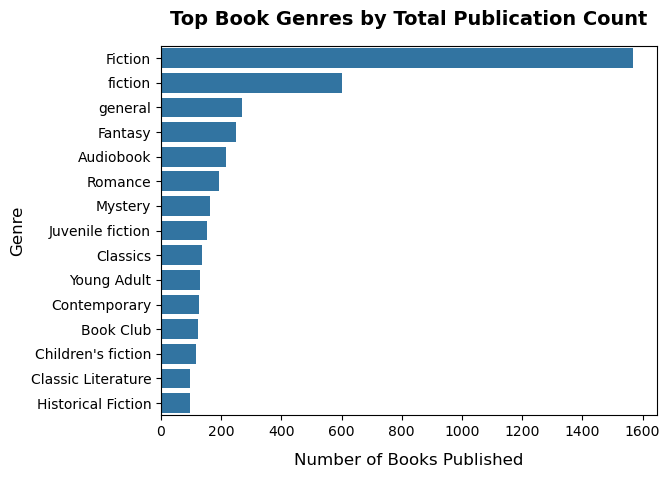

In [48]:
sns.barplot(
    data=top_genres,
    x="book_count",
    y="genre")
plt.title("Top Book Genres by Total Publication Count", fontsize=14, pad=15, weight="bold")
plt.xlabel("Number of Books Published", fontsize=12, labelpad=10)
plt.ylabel("Genre", fontsize=12)
